# The Egg Fox effect

In this tutorial ,we mainly focus on the how to reduce the Egg Box effect 
 - Increase the MessCutoff :- 
     A finer grid reduces numerical noise and makes the representaion closer to continous space
 - Used Grid cell Sampling :-
     This average results over shifted grid to reduce sensistivity to a single fixed graid allignment

Now the a new block, which was already present (but not introduced) in the previous example appears :

                   %block AtomicCoordinatesOrigin
                   0.0 0.0 0.0
                   %endblock AtomicCoordinatesOrigin

* The block %block AtomicCoordinatesOrigin tells the program where the reference point for all your atom coordinates is located. By default, it’s set to (0.0 0.0 0.0).

We change the origin slightly to see how the total energy of the system varies when the entire structure is shifted relative to the simulation grid. By tracking how the energy changes with each shift, we can estimate the magnitude of the eggbox error.

The size of each shift depends on the mesh settings. For example, if the mesh is
MESH = 18 × 18 × 30, then the z-direction is divided into 30 grid points. The distance between two neighboring grid points corresponds to a normalized value of 1/30.

To sample the energy more accurately, we further divide this small distance into 6 equal steps. The step size is therefore:

                                   Step size = (1/30) ×(1/6) = 1/180


For each shift, the z-coordinate of the origin is increased by 1/180 (≈ 0.00555). This process is repeated until all 6 shifts are completed.

In [1]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/grid-convergence/02-MgO


In [2]:
ls

 MgO.fdf   Mg.psml   O.psml  'Tutorial 4 Ex 2.ipynb'


In [3]:
# modify the fdf manually

In [3]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/grid-convergence/02-MgO


In [4]:
ls

 MgO.fdf   Mg.psml   O.psml  'Tutorial 4 Ex 2.ipynb'


In [15]:
%%bash

# Z-shifts (egg-box sampling: 0.0 → 1.0 in steps of 0.1)
shifts=(0.0 0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.0)

for i in "${!shifts[@]}"; do
    dir="shift_$i"
    mkdir -p "$dir"

    # Copy input files
    cp MgO.fdf "$dir/"
    cp Mg.psml O.psml "$dir/"

    # Replace ZSHIFT with the actual value
    sed -i "s/ZSHIFT/${shifts[$i]}/g" "$dir/MgO.fdf"

    # Run SIESTA
    cd "$dir"
    siesta < MgO.fdf > MgO.out
    cd ..
done


Gamma-point calculation with interaction between periodic images
Some features might not work optimally:
e.g. DM initialization from atomic data
Job completed
Gamma-point calculation with interaction between periodic images
Some features might not work optimally:
e.g. DM initialization from atomic data
Job completed
Gamma-point calculation with interaction between periodic images
Some features might not work optimally:
e.g. DM initialization from atomic data
Job completed
Gamma-point calculation with interaction between periodic images
Some features might not work optimally:
e.g. DM initialization from atomic data
Job completed
Gamma-point calculation with interaction between periodic images
Some features might not work optimally:
e.g. DM initialization from atomic data
Job completed
Gamma-point calculation with interaction between periodic images
Some features might not work optimally:
e.g. DM initialization from atomic data
Job completed
Gamma-point calculation with interaction betwe

In [23]:
import re

def extract_vals(file):
    E = F = T = None
    with open(file) as f:
        for line in f:
            # ---- Total energy ----
            if "siesta:" in line and "Total =" in line:
                nums = re.findall(r"[-+]?\d+\.\d+", line)
                if nums:
                    E = float(nums[0])

            # ---- Max force ----
            if line.strip().startswith("Max"):
                nums = re.findall(r"[-+]?\d+\.\d+", line)
                if nums:
                    F = float(nums[0])

            # ---- CPU / wall time ----
            if "Total elapsed time" in line or "timer:" in line:
                nums = re.findall(r"[-+]?\d+\.\d+", line)
                if nums:
                    T = float(nums[-1])

    return E, F, T


# Z-shifts (MATCHES bash script: 0 → 0.1 in steps of 0.00555)
shifts = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    


print("ZSHIFT     TotalEnergy(eV)   MaxForce(eV/Å)   CPUtime(s)")
print("-------------------------------------------------------")

for i in range(len(shifts)):
    outfile = f"shift_{i}/MgO.out"
    E, F, T = extract_vals(outfile)

    print(f"{zshifts[i]:7.5f}   {E:16.6f}   {F:14.6f}   {T:10.2f}")


ZSHIFT     TotalEnergy(eV)   MaxForce(eV/Å)   CPUtime(s)
-------------------------------------------------------
0.00000       -4110.480711         0.000000         0.54
0.00555       -4110.480711         0.000000         0.53
0.01110       -4110.480711         0.000000         0.52
0.01665       -4110.480711         0.000000         0.52
0.02220       -4110.480711         0.000000         0.54
0.02775       -4110.480711         0.000000         0.53
0.03330       -4110.480711         0.000000         0.52
0.03885       -4110.480711         0.000000         0.53
0.04440       -4110.480711         0.000000         0.54
0.04995       -4110.480711         0.000000         0.53
0.05550       -4110.480711         0.000000         0.54


In [12]:
%%bash

# Z-shift parameters
start=0.0
step=0.00555
end=0.1

i=0
shift=$start

while (( $(echo "$shift <= $end" | bc -l) )); do
    dir="shift_$i"
    mkdir -p "$dir"

    # Copy input files
    cp MgO.fdf "$dir/"
    cp Mg.psml O.psml "$dir/"

    # Replace ZSHIFT with actual value
    sed -i "s/ZSHIFT/$shift/g" "$dir/MgO.fdf"

    # Run SIESTA
    cd "$dir"
    siesta < MgO.fdf > MgO.out
    cd ..

    # Increment
    shift=$(echo "$shift + $step" | bc -l)
    i=$((i + 1))
done


Gamma-point calculation with interaction between periodic images
Some features might not work optimally:
e.g. DM initialization from atomic data
Job completed
Gamma-point calculation with interaction between periodic images
Some features might not work optimally:
e.g. DM initialization from atomic data
Job completed
Gamma-point calculation with interaction between periodic images
Some features might not work optimally:
e.g. DM initialization from atomic data
Job completed
Gamma-point calculation with interaction between periodic images
Some features might not work optimally:
e.g. DM initialization from atomic data
Job completed
Gamma-point calculation with interaction between periodic images
Some features might not work optimally:
e.g. DM initialization from atomic data
Job completed
Gamma-point calculation with interaction between periodic images
Some features might not work optimally:
e.g. DM initialization from atomic data
Job completed
Gamma-point calculation with interaction betwe

In [13]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/grid-convergence/02-MgO


After successfully executed the sieta , now were going to extract the total energy value ,maximum forces,time for computation

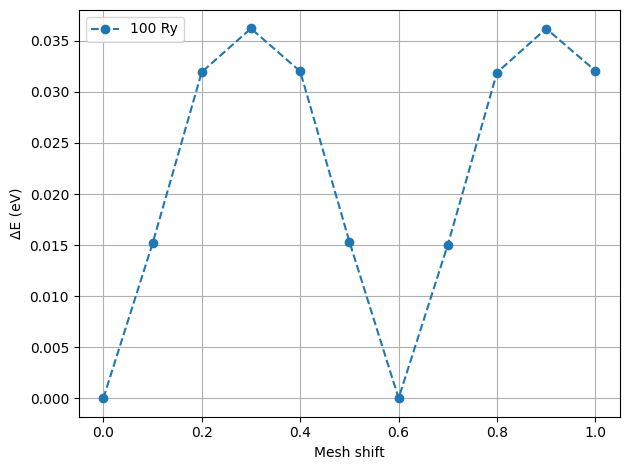

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import re
import glob

# =========================
# USER SETTINGS
# =========================
n_shifts = 11          # 0.0 → 1.0 in steps of 0.1
step = 0.1
label = "100 Ry"       # change to "200 Ry" for second run
marker = "o--"

# =========================
# Extract total energy
# =========================


def extract_energy(outfile):
    with open(outfile) as f:
        for line in f:
            if "Total =" in line:
                nums = re.findall(r"[-+]?\d+\.\d+", line)
                if nums:
                    return float(nums[0])
    raise RuntimeError("Total energy not found")

# =========================
# Read data
# =========================
shifts = np.array([i * step for i in range(n_shifts)])
energies = []

for i in range(n_shifts):
    outfile = f"shift_{i}/MgO.out"
    E = extract_energy(outfile)
    energies.append(E)

energies = np.array(energies)

# =========================
# Compute ΔE
# =========================
dE = energies - energies.min()

# =========================
# Plot
# =========================
plt.plot(shifts, dE, marker, label=label)
plt.xlabel("Mesh shift")
plt.ylabel("ΔE (eV)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
import re

def extract_vals(file):
    E = F = T = None
    with open(file) as f:
        for line in f:
            # ---- Total energy ----
            if "siesta:" in line and "Total =" in line:
                nums = re.findall(r"[-+]?\d+\.\d+", line)
                if nums:
                    E = float(nums[0])

            # ---- Max force ----
            if line.strip().startswith("Max"):
                nums = re.findall(r"[-+]?\d+\.\d+", line)
                if nums:
                    F = float(nums[0])

            # ---- CPU / wall time ----
            if "Total elapsed time" in line or "timer:" in line:
                nums = re.findall(r"[-+]?\d+\.\d+", line)
                if nums:
                    T = float(nums[-1])

    return E, F, T


# Z-shifts used (must match your SIESTA runs)
zshifts = [0.00000, 0.00555, 0.01110, 0.01665, 0.02220, 0.02775]

print("ZSHIFT     TotalEnergy(eV)   MaxForce(eV/Å)   CPUtime(s)")
print("-------------------------------------------------------")

for i in range(len(zshifts)):
    outfile = "shift_" + str(i) + "/MgO.out"
    E, F, T = extract_vals(outfile)

    print(f"{zshifts[i]:7.5f}   {E:16.6f}   {F:14.6f}   {T:10.2f}")


ZSHIFT     TotalEnergy(eV)   MaxForce(eV/Å)   CPUtime(s)
-------------------------------------------------------
0.00000       -4110.480711         0.000000         0.45
0.00555       -4110.480711         0.000000         0.44
0.01110       -4110.480711         0.000000         0.45
0.01665       -4110.480711         0.000000         0.46
0.02220       -4110.480711         0.000000         0.47
0.02775       -4110.480711         0.000000         0.45


In [8]:
import re

def extract_vals(file):
    E = F = T = None
    with open(file) as f:
        for line in f:
            # ---- Total energy ----
            if "siesta:" in line and "Total =" in line:
                nums = re.findall(r"[-+]?\d+\.\d+", line)
                if nums:
                    E = float(nums[0])

            # ---- Max force ----
            if line.strip().startswith("Max"):
                nums = re.findall(r"[-+]?\d+\.\d+", line)
                if nums:
                    F = float(nums[0])

            # ---- CPU / wall time ----
            if "Total elapsed time" in line or "timer:" in line:
                nums = re.findall(r"[-+]?\d+\.\d+", line)
                if nums:
                    T = float(nums[-1])

    return E, F, T


# Z-shifts used (must match your SIESTA runs)
zshifts = [0.00000, 0.00555, 0.01110, 0.01665, 0.02220, 0.02775]

print("ZSHIFT     TotalEnergy(eV)   MaxForce(eV/Å)   CPUtime(s)")
print("-------------------------------------------------------")

for i in range(len(zshifts)):
    outfile = "shift_" + str(i) + "/MgO.out"
    E, F, T = extract_vals(outfile)

    print(f"{zshifts[i]:7.5f}   {E:16.6f}   {F:14.6f}   {T:10.2f}")


ZSHIFT     TotalEnergy(eV)   MaxForce(eV/Å)   CPUtime(s)
-------------------------------------------------------
0.00000       -4110.480711         0.000000         0.45
0.00555       -4110.480711         0.000000         0.44
0.01110       -4110.480711         0.000000         0.45
0.01665       -4110.480711         0.000000         0.46
0.02220       -4110.480711         0.000000         0.47
0.02775       -4110.480711         0.000000         0.45


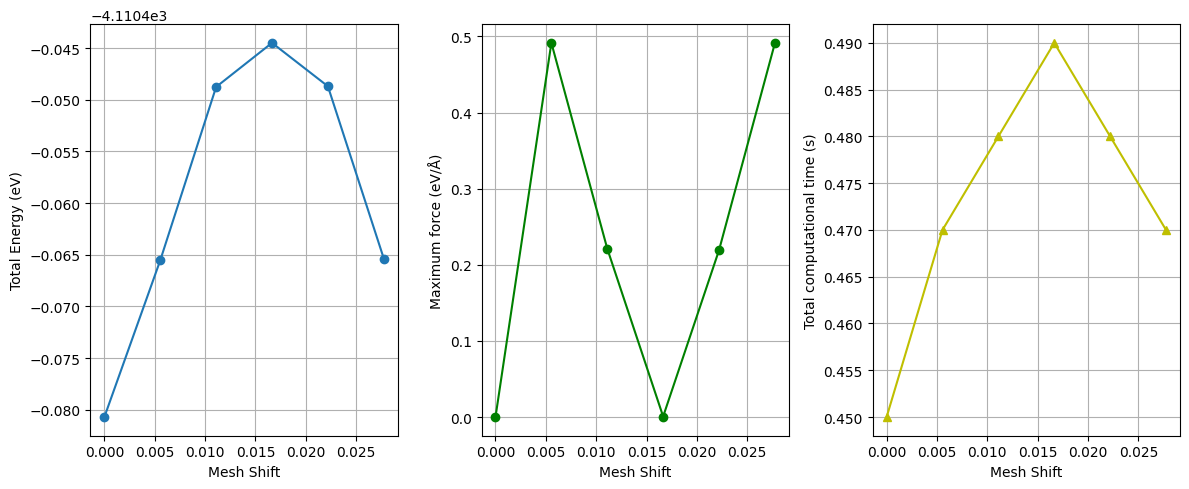

In [1]:
import matplotlib.pyplot as plt

# Egg-box data
zshift = [0.00000, 0.00555, 0.01110, 0.01665, 0.02220, 0.02775]

energy = [
    -4110.480711,
    -4110.465544,
    -4110.448760,
    -4110.444496,
    -4110.448698,
    -4110.465368
]
force = [
    0.000000,
    0.491547,
    0.221220,
    0.000663,
    0.219157,
    0.491216
]
time = [0.45, 0.47, 0.48, 0.49, 0.48, 0.47]
# for simplicity give the extract data directly as an array
plt.figure(figsize=(12,5))

# ---- Energy vs shift ----
plt.subplot(1,3,1)
plt.plot(zshift, energy, marker='o')
plt.xlabel("Mesh Shift")
plt.ylabel("Total Energy (eV)")
     #-------give inverted output----
plt.grid(True)

# ---- Shift vs Maximum force ----
plt.subplot(1,3,2)
plt.plot(zshift, force, marker='o',color='g')
plt.xlabel("Mesh Shift")
plt.ylabel("Maximum force (eV/Å)")
plt.grid(True)

# ---- Shift vs Time ----
plt.subplot(1,3,3)
plt.plot(zshift, time, marker='^',color="y")
plt.xlabel("Mesh Shift")
plt.ylabel("Total computational time (s)")
plt.grid(True)

plt.tight_layout()
plt.show()




In [2]:
!cat MgO.fdf

SystemName          MgO tetragonal
SystemLabel         MgO
 
NumberOfAtoms       4
NumberOfSpecies     2

LatticeConstant 1 Ang 
%block LatticeVectors
       2.981000000        0.000000000        0.000000000
       0.000000000        2.981000000        0.000000000
       0.000000000        0.000000000        4.217000000
%endblock LatticeVectors
 
%block ChemicalSpeciesLabel
  1   12  Mg
  2    8  O 
%endblock ChemicalSpeciesLabel

PAO.BasisSize      DZ
 
AtomicCoordinatesFormat Fractional
%block AtomicCoordinatesAndAtomicSpecies
     0.0       0.0      0.0    1
     0.0       0.0      0.5    2
     0.5       0.5      0.5    1
     0.5       0.5      0.0    2
%endblock AtomicCoordinatesAndAtomicSpecies
%block AtomicCoordinatesOrigin
 0.0 0.0 ZSHIFT
%endblock AtomicCoordinatesOrigin

MeshCutoff          100 Ry
MaxSCFIterations    250
SCF.Mixer.Weight    0.15
SCF.Mixer.History   3
SCF.DM.Tolerance    1.0d-4

SolutionMethod         diagon
ElectronicTemperature  25 meV

LongOutput   T
UseTr